# 01 Training Result Review - finetune_v1

이 노트북은 Colab에서 실행한 `00_finetune_v1_colab.ipynb`의 결과를 로컬에서 분석하기 위한 노트북임.

분석 대상:

```text
colab_outputs/finetune_v1/
├─ MapLane_Field1Field2_smoke/
└─ MapLane_Field1Field2_full/
```

이 노트북에서 하는 것:

- smoke/full output 폴더 구조 확인
- checkpoint 파일 확인
- `log.txt`에서 training loss와 validation metric 파싱
- epoch별 loss 흐름 확인
- v1 학습이 정상적으로 끝났는지 판단

이 노트북에서 아직 하지 않는 것:

- pretrained vs fine-tuned lane output 시각 비교
- holdout/background 이미지 inference
- ONNX export
- Pi runtime 측정


## 1. 경로 설정

VS Code에서 이 노트북을 열면 보통 현재 작업 디렉토리가 `notebooks`이거나 실험 폴더일 수 있음. 아래 셀은 현재 위치에서 `06_lane_model_finetuning` 폴더를 찾아보고, 실패하면 절대경로 fallback을 사용함.


In [1]:
from pathlib import Path
import re
import json
from datetime import datetime

try:
    import pandas as pd
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError('이 노트북은 pandas와 matplotlib이 필요함. 현재 kernel 환경을 확인해야 함.') from e

FALLBACK_EXP_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning')

def find_exp_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == '06_lane_model_finetuning':
            return p
    return FALLBACK_EXP_ROOT

EXP_ROOT = find_exp_root()
OUTPUT_ROOT = EXP_ROOT / 'colab_outputs' / 'finetune_v1'
SMOKE_ROOT = OUTPUT_ROOT / 'MapLane_Field1Field2_smoke'
FULL_ROOT = OUTPUT_ROOT / 'MapLane_Field1Field2_full'

print('EXP_ROOT:', EXP_ROOT)
print('OUTPUT_ROOT exists:', OUTPUT_ROOT.exists(), OUTPUT_ROOT)
print('SMOKE_ROOT exists:', SMOKE_ROOT.exists())
print('FULL_ROOT exists:', FULL_ROOT.exists())

assert OUTPUT_ROOT.exists(), OUTPUT_ROOT
assert SMOKE_ROOT.exists(), SMOKE_ROOT
assert FULL_ROOT.exists(), FULL_ROOT


EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning
OUTPUT_ROOT exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1
SMOKE_ROOT exists: True
FULL_ROOT exists: True


## 2. 결과 폴더와 checkpoint 확인

full 학습 결과에서는 `ckpt/1.pth`, `3.pth`, `5.pth`, `7.pth`, `9.pth`, `11.pth`, `best.pth`가 생성되어야 함. `save_ep=2`이고 epoch index가 0부터 시작하므로 홀수 번호 checkpoint가 생성되는 형태임.


In [2]:
def find_single_run_dir(root: Path) -> Path:
    runs = sorted([p for p in root.iterdir() if p.is_dir()])
    if len(runs) != 1:
        print('run dirs:', runs)
        raise RuntimeError(f'expected exactly one run dir under {root}, got {len(runs)}')
    return runs[0]

SMOKE_RUN = find_single_run_dir(SMOKE_ROOT)
FULL_RUN = find_single_run_dir(FULL_ROOT)

print('SMOKE_RUN:', SMOKE_RUN)
print('FULL_RUN:', FULL_RUN)

ckpts = []
for kind, run in [('smoke', SMOKE_RUN), ('full', FULL_RUN)]:
    for p in sorted((run / 'ckpt').glob('*.pth')):
        ckpts.append({
            'kind': kind,
            'name': p.name,
            'path': str(p),
            'size_mb': round(p.stat().st_size / 1024 / 1024, 2),
            'modified': datetime.fromtimestamp(p.stat().st_mtime),
        })
ckpt_df = pd.DataFrame(ckpts)
ckpt_df


SMOKE_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_smoke\20260505_200147_lr_1e-04_b_8
FULL_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8


,kind,name,path,size_mb,modified
0,smoke,0.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 13:07:26
1,smoke,best.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 13:11:18
2,full,1.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 13:28:02
3,full,11.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 14:22:54
4,full,3.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 13:39:02
5,full,5.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 13:50:00
6,full,7.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 14:01:00
7,full,9.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 14:11:56
8,full,best.pth,~\02_Projects\University\26-1_Em...,131.63,2026-05-05 14:27:44


## 3. log.txt 파싱

공식 runner의 `log.txt`에서 다음을 파싱함.

- step별 training loss
- `cls_loss`, `reg_xytl_loss`, `seg_loss`, `iou_loss`
- validation metric
- best metric / best epoch


In [3]:
TRAIN_RE = re.compile(
    r'epoch:\s+(?P<epoch>\d+)\s+'
    r'step:\s+(?P<step>\d+)\s+'
    r'lr:\s+(?P<lr>[0-9.]+)\s+'
    r'loss:\s+(?P<loss>[0-9.]+)\s+'
    r'cls_loss:\s+(?P<cls_loss>[0-9.]+)\s+'
    r'reg_xytl_loss:\s+(?P<reg_xytl_loss>[0-9.]+)\s+'
    r'seg_loss:\s+(?P<seg_loss>[0-9.]+)\s+'
    r'iou_loss:\s+(?P<iou_loss>[0-9.]+)\s+'
    r'stage_0_acc:\s+(?P<stage_0_acc>[0-9.]+)'
)
METRIC_RE = re.compile(r'metric:\s+([0-9.]+)')
BEST_RE = re.compile(r'Best metric:\s+([0-9.]+)\s+epoch_best:(\d+)')
VAL_IOU_RE = re.compile(
    r'iou thr:\s+(?P<iou_thr>[0-9.]+),\s+'
    r'tp:\s+(?P<tp>\d+),\s+'
    r'fp:\s+(?P<fp>\d+),\s+'
    r'fn:\s+(?P<fn>\d+),precision:\s+(?P<precision>[0-9.]+),\s+'
    r'recall:\s+(?P<recall>[0-9.]+),\s+'
    r'f1:\s+(?P<f1>[0-9.]+)'
)

def parse_log(log_path: Path, kind: str):
    rows = []
    metrics = []
    best = None
    val_rows = []
    lines = log_path.read_text(encoding='utf-8', errors='replace').splitlines()
    current_eval_list = None
    for line in lines:
        if 'Calculating metric for List:' in line:
            current_eval_list = line.split('Calculating metric for List:', 1)[1].strip()
        m = TRAIN_RE.search(line)
        if m:
            d = m.groupdict()
            d['kind'] = kind
            d['epoch'] = int(d['epoch'])
            d['step'] = int(d['step'])
            for key in ['lr', 'loss', 'cls_loss', 'reg_xytl_loss', 'seg_loss', 'iou_loss', 'stage_0_acc']:
                d[key] = float(d[key])
            rows.append(d)
        m = METRIC_RE.search(line)
        if m:
            metrics.append(float(m.group(1)))
        m = BEST_RE.search(line)
        if m:
            best = {'kind': kind, 'best_metric': float(m.group(1)), 'epoch_best': int(m.group(2))}
        m = VAL_IOU_RE.search(line)
        if m:
            d = m.groupdict()
            d['kind'] = kind
            d['eval_list'] = current_eval_list
            d['iou_thr'] = float(d['iou_thr'])
            for key in ['tp', 'fp', 'fn']:
                d[key] = int(d[key])
            for key in ['precision', 'recall', 'f1']:
                d[key] = float(d[key])
            val_rows.append(d)
    return {
        'train': pd.DataFrame(rows),
        'metrics': metrics,
        'best': best,
        'val': pd.DataFrame(val_rows),
        'line_count': len(lines),
        'log_path': str(log_path),
    }

smoke = parse_log(SMOKE_RUN / 'log.txt', 'smoke')
full = parse_log(FULL_RUN / 'log.txt', 'full')

train_df = pd.concat([smoke['train'], full['train']], ignore_index=True)
val_df = pd.concat([smoke['val'], full['val']], ignore_index=True)
best_df = pd.DataFrame([smoke['best'], full['best']])

print('smoke log lines:', smoke['line_count'])
print('full log lines:', full['line_count'])
print('train rows:', len(train_df))
print('val rows:', len(val_df))
best_df


smoke log lines: 366
full log lines: 882
train rows: 608
val rows: 38


,kind,best_metric,epoch_best
0,smoke,0.391978,0
1,full,0.476076,11


## 4. 학습 요약

여기서 보는 것은 “실제 주행 성능”이 아니라, **학습이 안정적으로 진행되었는지**임.

특히 확인할 것:

- loss가 `nan` 없이 내려갔는가
- `reg_xytl_loss`, `iou_loss`가 같이 내려갔는가
- full 학습의 final/best metric이 smoke보다 나아졌는가


In [4]:
def summarize_train(df: pd.DataFrame):
    return pd.DataFrame([
        {
            'kind': kind,
            'first_epoch': int(g['epoch'].iloc[0]),
            'last_epoch': int(g['epoch'].iloc[-1]),
            'first_step': int(g['step'].iloc[0]),
            'last_step': int(g['step'].iloc[-1]),
            'first_loss': g['loss'].iloc[0],
            'last_loss': g['loss'].iloc[-1],
            'min_loss': g['loss'].min(),
            'last_reg_xytl_loss': g['reg_xytl_loss'].iloc[-1],
            'last_iou_loss': g['iou_loss'].iloc[-1],
            'last_seg_loss': g['seg_loss'].iloc[-1],
        }
        for kind, g in df.groupby('kind', sort=False)
    ])

summary_df = summarize_train(train_df)
summary_df


,kind,first_epoch,last_epoch,first_step,last_step,first_loss,last_loss,min_loss,last_reg_xytl_loss,last_iou_loss,last_seg_loss
0,smoke,0,0,1,901,6.0802,2.7967,2.7313,0.6049,1.3184,0.1242
1,full,0,11,1,10847,6.0802,1.8274,1.5765,0.3874,0.7661,0.0997


In [5]:
epoch_summary = (
    train_df
    .groupby(['kind', 'epoch'], as_index=False)
    .agg(
        logs=('loss', 'size'),
        first_step=('step', 'first'),
        last_step=('step', 'last'),
        mean_loss=('loss', 'mean'),
        last_loss=('loss', 'last'),
        mean_reg_xytl_loss=('reg_xytl_loss', 'mean'),
        mean_iou_loss=('iou_loss', 'mean'),
        mean_seg_loss=('seg_loss', 'mean'),
        mean_cls_loss=('cls_loss', 'mean'),
    )
)
epoch_summary


,kind,epoch,logs,first_step,last_step,mean_loss,last_loss,mean_reg_xytl_loss,mean_iou_loss,mean_seg_loss,mean_cls_loss
0,full,0,47,1,906,3.172177,2.6903,0.751379,1.477838,0.135226,0.807743
1,full,1,47,907,1812,2.628389,2.6347,0.532428,1.192051,0.112172,0.791747
2,full,2,47,1813,2718,2.417281,2.3462,0.486687,1.068745,0.107277,0.754566
3,full,3,47,2719,3624,2.268355,2.3357,0.470611,0.981723,0.104287,0.711732
4,full,4,47,3625,4530,2.135481,1.8722,0.446702,0.909996,0.102166,0.676619
5,full,5,47,4531,5436,2.025832,1.9187,0.431655,0.859430,0.101170,0.633568
6,full,6,47,5437,6342,1.961462,1.8263,0.413147,0.827615,0.100357,0.620345
7,full,7,47,6343,7248,1.897138,2.0889,0.398704,0.796911,0.099402,0.602104
8,full,8,47,7249,8154,1.850053,1.6695,0.391806,0.769862,0.098915,0.589470
9,full,9,47,8155,9060,1.816198,1.8314,0.381179,0.755400,0.098451,0.581157


## 5. Loss 그래프

v1에서는 loss가 대략 다음 흐름이면 정상으로 봄.

```text
초기 6 전후
-> smoke 1 epoch 후 2.8~3.0 전후
-> full 후반 1.x~2.x 전후
```

다만 loss는 pseudo-label 기준이므로, 최종 판단은 다음 노트북의 holdout 시각 비교로 해야 함.


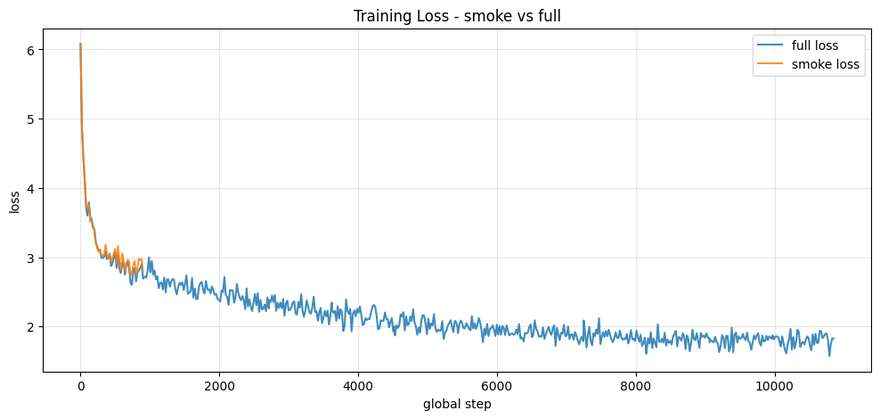

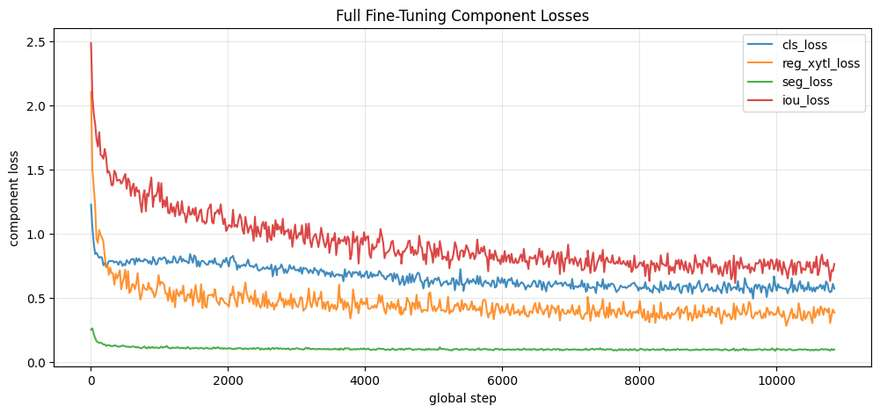

In [6]:
plt.figure(figsize=(12, 5))
for kind, g in train_df.groupby('kind'):
    plt.plot(g['step'], g['loss'], label=f'{kind} loss', alpha=0.85)
plt.xlabel('global step')
plt.ylabel('loss')
plt.title('Training Loss - smoke vs full')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
full_df = train_df[train_df['kind'] == 'full']
for col in ['cls_loss', 'reg_xytl_loss', 'seg_loss', 'iou_loss']:
    plt.plot(full_df['step'], full_df[col], label=col, alpha=0.85)
plt.xlabel('global step')
plt.ylabel('component loss')
plt.title('Full Fine-Tuning Component Losses')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


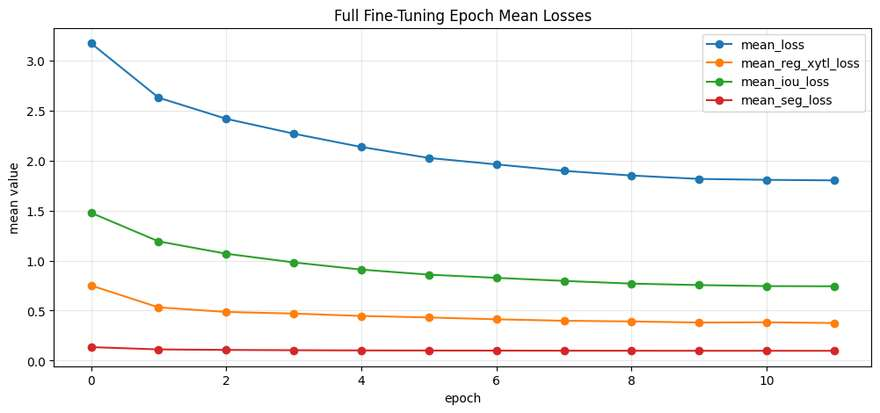

In [7]:
plt.figure(figsize=(12, 5))
full_epoch = epoch_summary[epoch_summary['kind'] == 'full']
plt.plot(full_epoch['epoch'], full_epoch['mean_loss'], marker='o', label='mean_loss')
plt.plot(full_epoch['epoch'], full_epoch['mean_reg_xytl_loss'], marker='o', label='mean_reg_xytl_loss')
plt.plot(full_epoch['epoch'], full_epoch['mean_iou_loss'], marker='o', label='mean_iou_loss')
plt.plot(full_epoch['epoch'], full_epoch['mean_seg_loss'], marker='o', label='mean_seg_loss')
plt.xlabel('epoch')
plt.ylabel('mean value')
plt.title('Full Fine-Tuning Epoch Mean Losses')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6. Validation metric 확인

현재 metric은 pseudo-label validation 기준임. 공식 CULane GT가 아니라 우리가 만든 pseudo-label과 비교하는 값이므로, 이 숫자만으로 실제 주행 성능을 확정하면 안 됨.

그래도 smoke 대비 full에서 F1@0.5가 올라갔다면, 적어도 pseudo-label을 더 잘 따라가도록 학습되었다고 볼 수 있음.


In [8]:
metric_summary = best_df.copy()
metric_summary['note'] = [
    '1 epoch smoke 기준',
    '12 epoch full 기준',
]
metric_summary


,kind,best_metric,epoch_best,note
0,smoke,0.391978,0,1 epoch smoke 기준
1,full,0.476076,11,12 epoch full 기준


In [9]:
# val.txt 기준 IoU threshold별 결과만 보기.
val_txt_df = val_df[val_df['eval_list'].str.endswith('/list/val.txt', na=False)].copy()
val_txt_df[['kind', 'iou_thr', 'precision', 'recall', 'f1', 'tp', 'fp', 'fn']]


,kind,iou_thr,precision,recall,f1,tp,fp,fn
9,smoke,0.50,0.308859,0.536308,0.391978,1935,4330,1673
10,smoke,0.55,0.302793,0.525776,0.384280,1897,4368,1711
11,smoke,0.60,0.293855,0.510255,0.372936,1841,4424,1767
12,smoke,0.65,0.275818,0.478936,0.350046,1728,4537,1880
13,smoke,0.70,0.240223,0.417129,0.304872,1505,4760,2103
14,smoke,0.75,0.192179,0.333703,0.243897,1204,5061,2404
15,smoke,0.80,0.116520,0.202328,0.147878,730,5535,2878
16,smoke,0.85,0.048364,0.083980,0.061380,303,5962,3305
17,smoke,0.90,0.009417,0.016353,0.011952,59,6206,3549
18,smoke,0.95,0.000319,0.000554,0.000405,2,6263,3606


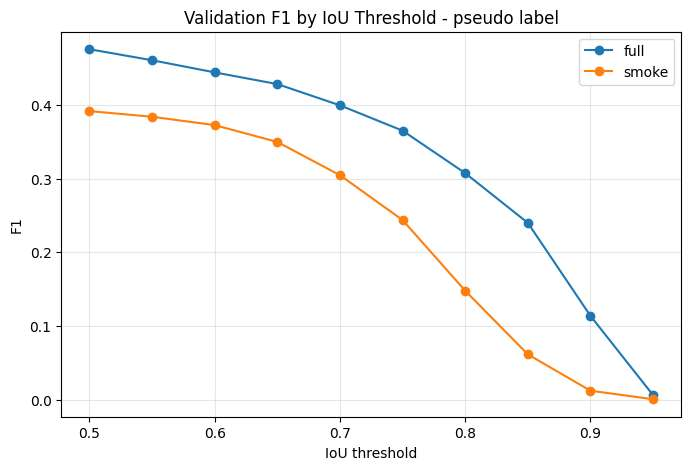

In [13]:
plt.figure(figsize=(8, 5))
for kind, g in val_txt_df.groupby('kind'):
    plt.plot(g['iou_thr'], g['f1'], marker='o', label=kind)
plt.xlabel('IoU threshold')
plt.ylabel('F1')
plt.title('Validation F1 by IoU Threshold - pseudo label')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. 사용할 checkpoint 후보

현재 v1에서 다음 노트북으로 넘길 1순위 후보는 full 학습의 `best.pth`임.

다만 공식 runner에서는 마지막 epoch가 best로 잡히는 경우가 많으므로, `11.pth`와 `best.pth`가 사실상 같은 성격인지도 다음 노트북에서 확인하면 좋음.


In [11]:
full_ckpt_df = ckpt_df[ckpt_df['kind'] == 'full'].copy()
full_ckpt_df[['name', 'size_mb', 'path']]


,name,size_mb,path
2,1.pth,131.63,~\02_Projects\University\26-1_Em...
3,11.pth,131.63,~\02_Projects\University\26-1_Em...
4,3.pth,131.63,~\02_Projects\University\26-1_Em...
5,5.pth,131.63,~\02_Projects\University\26-1_Em...
6,7.pth,131.63,~\02_Projects\University\26-1_Em...
7,9.pth,131.63,~\02_Projects\University\26-1_Em...
8,best.pth,131.63,~\02_Projects\University\26-1_Em...


In [12]:
BEST_CKPT = FULL_RUN / 'ckpt' / 'best.pth'
LAST_CKPT = FULL_RUN / 'ckpt' / '11.pth'
SMOKE_BEST_CKPT = SMOKE_RUN / 'ckpt' / 'best.pth'

print('BEST_CKPT exists:', BEST_CKPT.exists(), BEST_CKPT)
print('LAST_CKPT exists:', LAST_CKPT.exists(), LAST_CKPT)
print('SMOKE_BEST_CKPT exists:', SMOKE_BEST_CKPT.exists(), SMOKE_BEST_CKPT)


BEST_CKPT exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\best.pth
LAST_CKPT exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\11.pth
SMOKE_BEST_CKPT exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_smoke\20260505_200147_lr_1e-04_b_8\ckpt\best.pth


## 8. 결과 메모

현재 로컬로 확인한 v1 결과는 다음과 같음.

```text
smoke first loss: 6.0802
smoke last loss: 2.7967
smoke best F1@0.5: 0.391978

full first loss: 6.0802
full last loss: 1.8274
full epoch 11 mean loss: 약 1.80
full best F1@0.5: 0.476076
best epoch: 11
```

판단:

- `ResNet18_CULane.pth`에서 field1+field2 pseudo dataset으로 fine-tuning 학습이 정상적으로 완료됨.
- loss는 `nan` 없이 내려갔고, full 후반 loss가 smoke보다 확실히 낮음.
- pseudo-label validation 기준 F1@0.5도 smoke보다 상승함.
- 따라서 v1은 “학습 파이프라인 성공”으로 판단 가능함.

아직 판단하면 안 되는 것:

- 실제 맵 주행 성능
- holdout/background에서 차선 출력이 정말 좋아졌는지
- Pi에서 latency가 괜찮은지

다음 작업:

```text
02_holdout_visual_compare_finetune_v1.ipynb
```

여기서 pretrained `ResNet18_CULane.pth`와 full fine-tuned `best.pth`를 같은 holdout/background 이미지에 돌려서 lane output을 직접 비교해야 함.
